# Patch-Based Inference

> Sliding-window inference for 3D medical image segmentation using fastMONAI's `PatchInferenceEngine`.

This tutorial demonstrates how to perform inference on trained patch-based models:

1. **GridSampler**: Extracts overlapping patches from the input volume
2. **Model**: Predicts on each patch
3. **GridAggregator**: Reconstructs the full volume with Hann windowing for smooth boundaries

**Prerequisites**: Run [12a_tutorial_patch_training.ipynb](12a_tutorial_patch_training.ipynb) first to train a model and save the configuration.

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MMIV-ML/fastMONAI/blob/main/nbs/12b_tutorial_patch_inference.ipynb)

In [ ]:
#| hide
#Install `fastMONAI` if notebook is running on Google Colab
try:
    import google.colab
    %pip install fastMONAI
    from fastMONAI.utils import print_colab_gpu_info
    print_colab_gpu_info()
except:
    print('Running locally')

Running locally


In [ ]:
from fastMONAI.vision_all import *

from monai.apps import DecathlonDataset
from sklearn.model_selection import train_test_split

### Load data

Load the same dataset and recreate the train/test split from the training notebook.

In [ ]:
path = Path('../data')
path.mkdir(exist_ok=True)

In [ ]:
task = "Task02_Heart"
training_data = DecathlonDataset(root_dir=path, task=task, section="training", 
    download=True, cache_num=0, num_workers=3)

2026-02-03 15:10:15,182 - INFO - Verified 'Task02_Heart.tar', md5: 06ee59366e1e5124267b774dbd654057.
2026-02-03 15:10:15,182 - INFO - File exists: ../data/Task02_Heart.tar, skipped downloading.
2026-02-03 15:10:15,183 - INFO - Non-empty folder exists in ../data/Task02_Heart, skipped extracting.


In [ ]:
df = pd.DataFrame(training_data.data)
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
print(f"Test samples: {len(test_df)}")
test_df

Test samples: 2


,image,label
0,../data/Task02_Heart/imagesTr/la_030.nii.gz,../data/Task02_Heart/labelsTr/la_030.nii.gz
1,../data/Task02_Heart/imagesTr/la_024.nii.gz,../data/Task02_Heart/labelsTr/la_024.nii.gz


### Load configuration

Load the patch configuration saved during training. This ensures preprocessing consistency:

- **apply_reorder**: Whether to reorder to RAS+ orientation
- **target_spacing**: Target voxel spacing for resampling
- **patch_size, patch_overlap, aggregation_mode**: Inference parameters

> **Critical**: Mismatched preprocessing parameters will produce incorrect predictions (e.g., mirrored or rotated outputs).

In [ ]:
config_dict = load_patch_variables('patch_config.pkl')
print("Loaded configuration:")
for k, v in config_dict.items():
    print(f"  {k}: {v}")

Loaded configuration:
  patch_size: [128, 128, 64]
  patch_overlap: 0.5
  aggregation_mode: hann
  apply_reorder: True
  target_spacing: [1.25, 1.25, 1.37]
  sampler_type: label
  label_probabilities: {0: 0.2, 1: 0.8}
  samples_per_volume: 8
  queue_length: 300
  queue_num_workers: 4
  keep_largest_component: True


In [ ]:
patch_config = PatchConfig(**config_dict)
apply_reorder = config_dict['apply_reorder']
target_spacing = config_dict['target_spacing']

### Load trained model

Load the exported learner which contains both the model architecture and best weights.

**Two options:**
1. **Local file**: Load `learner.pkl` exported during training
2. **MLflow**: Download from MLflow artifacts (for experiment tracking workflows)

In [ ]:
from fastai.learner import load_learner
import torch

# Option 1: Load from local file
learn = load_learner('models/learner.pkl')

# Option 2: Load from MLflow (uncomment to use)
# import mlflow
# run_id = "your_run_id"  # Get from MLflow UI
# mlflow.artifacts.download_artifacts(run_id=run_id, artifact_path="model/learner.pkl", dst_path="./")
# learn = load_learner('learner.pkl')

model = learn.model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

print(f"Loaded model: {model.__class__.__name__}")
print(f"Device: {device}")

load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.


Loaded model: UNet
Device: cuda


### Define pre-inference transforms

These transforms **MUST match** the `pre_patch_tfms` used during training.

> **Troubleshooting**: If predictions appear mirrored, rotated, or completely wrong, check that `apply_reorder`, `target_spacing`, and `pre_inference_tfms` match training.

In [ ]:
# MUST match training pre_patch_tfms
pre_inference_tfms = [ZNormalization()]

### Create PatchInferenceEngine

The engine handles the complete sliding-window inference pipeline:
1. Load and preprocess the image (reorder, resample, normalize)
2. Pad if image is smaller than patch size
3. Extract overlapping patches with GridSampler
4. Predict on batches of patches
5. Reconstruct full volume with GridAggregator using Hann windowing

In [ ]:
engine = PatchInferenceEngine(
    learner=model,  # Pass model directly (no Learner needed)
    config=patch_config,
    pre_inference_tfms=pre_inference_tfms,
    batch_size=4
)

### Single image inference

Use `engine.predict()` to predict on a single image.

In [ ]:
test_path = test_df.iloc[0]['image']
pred, affine = engine.predict(test_path, return_affine=True)
print(f"Input: {test_path}")
print(f"Prediction shape: {pred.shape}")
print(f"Unique values: {torch.unique(pred).tolist()}")

Input: ../data/Task02_Heart/imagesTr/la_030.nii.gz
Prediction shape: torch.Size([1, 320, 320, 110])
Unique values: [0, 1]


### Batch inference

Use `patch_inference()` to predict on multiple images with optional NIfTI output.

In [ ]:
test_paths = test_df['image'].tolist()

predictions = patch_inference(
    learner=model,  # Pass model directly (no Learner needed)
    config=patch_config,
    file_paths=test_paths,
    pre_inference_tfms=pre_inference_tfms,
    save_dir='predictions/patch_heart',
    progress=True
)

print(f"\nGenerated {len(predictions)} predictions")
print(f"Saved to: predictions/patch_heart/")

Patch inference:   0%|          | 0/2 [00:00<?, ?it/s]


Generated 2 predictions
Saved to: predictions/patch_heart/


### Evaluate predictions

Evaluate predictions against ground truth using comprehensive metrics.

**Metrics:**
- **DSC**: Dice score - overlap similarity (higher = better)
- **HD95**: 95th percentile Hausdorff distance in voxels (lower = better)
- **Sens**: Sensitivity - true positive rate (higher = better)
- **LDR**: Lesion detection rate (higher = better)
- **RVE**: Relative volume error (0 = optimal, + = over-seg, - = under-seg)

In [ ]:
from fastMONAI.vision_metrics import (calculate_dsc, calculate_haus,
                                       calculate_confusion_metrics,
                                       calculate_lesion_detection_rate,
                                       calculate_signed_rve)

results = []

for i, pred in enumerate(predictions):
    img_name = Path(test_df.iloc[i]['image']).name
    gt_path = test_df.iloc[i]['label']

    # Load ground truth with matching preprocessing
    gt = MedMask.create(gt_path, apply_reorder=apply_reorder, target_spacing=target_spacing)

    # Prepare 5D tensors [B, C, D, H, W]
    pred_5d = pred.unsqueeze(0).float()
    gt_5d = gt.data.unsqueeze(0).float()

    # Compute metrics using calculate_* functions (for binary masks)
    dsc = calculate_dsc(pred_5d, gt_5d).mean().item()
    hd95 = calculate_haus(pred_5d, gt_5d).mean().item()
    sens = calculate_confusion_metrics(pred_5d, gt_5d, "sensitivity").nanmean().item()
    ldr = calculate_lesion_detection_rate(pred_5d, gt_5d).nanmean().item()
    rve = calculate_signed_rve(pred_5d, gt_5d).nanmean().item()

    results.append({
        'Image': img_name, 'DSC': dsc, 'HD95': hd95,
        'Sens': sens, 'LDR': ldr, 'RVE': rve
    })

results_df = pd.DataFrame(results)
results_df

monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.


,Image,DSC,HD95,Sens,LDR,RVE
0,la_030.nii.gz,0.938002,3.000000,0.918056,1.0,-0.042528
1,la_024.nii.gz,0.922835,3.316625,0.907937,1.0,-0.032287


In [ ]:
metrics = ['DSC', 'HD95', 'Sens', 'LDR', 'RVE']

print("Test Set Performance Summary")
print("=" * 45)
for metric in metrics:
    mean = results_df[metric].mean()
    std = results_df[metric].std()
    print(f"{metric:8s}: {mean:.4f} ± {std:.4f}")

Test Set Performance Summary
DSC     : 0.9304 ± 0.0107
HD95    : 3.1583 ± 0.2239
Sens    : 0.9130 ± 0.0072
LDR     : 1.0000 ± 0.0000
RVE     : -0.0374 ± 0.0072


### Visualize predictions

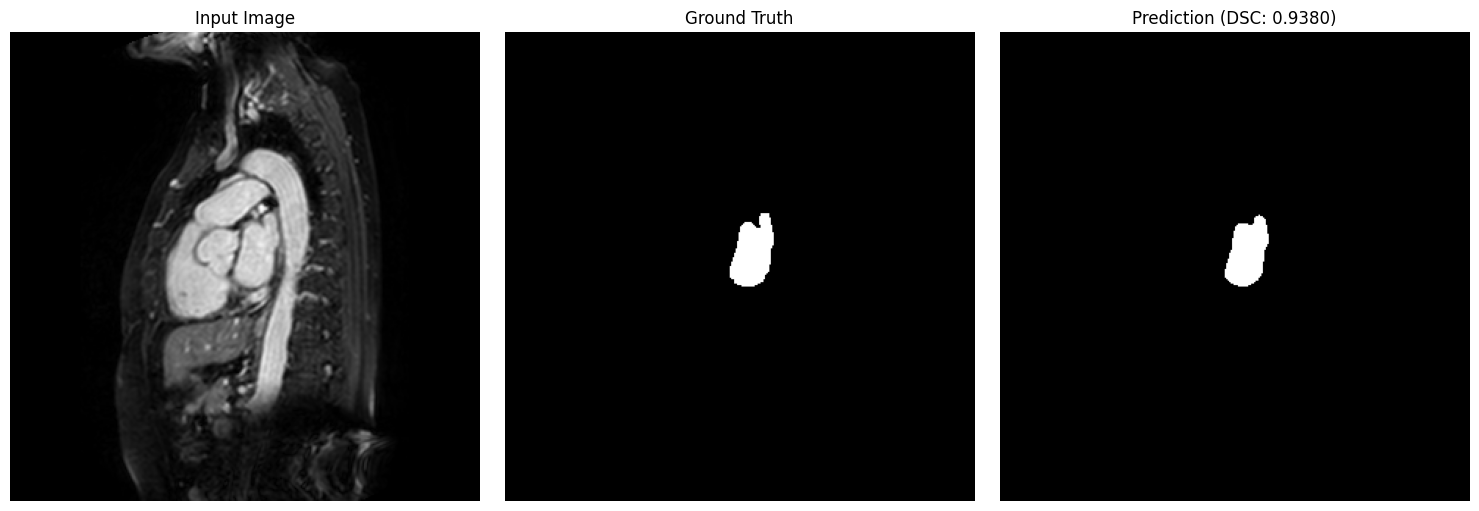

In [ ]:
from fastMONAI.vision_plot import show_segmentation_comparison

# Visualize first test case
idx = 0
test_img = MedImage.create(
    test_df.iloc[idx]['image'],
    apply_reorder=apply_reorder,
    target_spacing=target_spacing
)
test_gt = MedMask.create(
    test_df.iloc[idx]['label'],
    apply_reorder=apply_reorder,
    target_spacing=target_spacing
)

show_segmentation_comparison(
    image=test_img,
    ground_truth=test_gt,
    prediction=predictions[idx],
    metric_value=results_df.iloc[idx]['DSC'],
    voxel_size=target_spacing,
    anatomical_plane=2  # axial view
)

### Summary

In this tutorial, we demonstrated patch-based inference for 3D medical image segmentation:

1. **`load_patch_variables()`**: Load configuration saved during training
2. **Direct weight loading**: Use `torch.load()` to load weights directly (no Learner/DataLoaders needed)
3. **`PatchInferenceEngine`**: Sliding-window inference with GridSampler and GridAggregator
4. **`patch_inference()`**: Batch inference with optional NIfTI output

**Key points**:
- Preprocessing parameters (`apply_reorder`, `target_spacing`, `pre_inference_tfms`) **MUST match** training
- Pass model directly to `PatchInferenceEngine` - no need for fastai Learner at inference time
- Hann windowing (`aggregation_mode='hann'`) produces smooth boundaries between patches
- `keep_largest_component=True` can clean up small spurious predictions

**When to use patch-based inference**:
- Large images that don't fit in GPU memory
- Variable-sized inputs (no resizing needed)
- Memory-constrained environments

**Tradeoffs**:
- Slower than full-image inference (multiple forward passes)
- Overlap and aggregation add computational overhead
- But enables processing of arbitrarily large volumes